# Notebook 04: Foundation Models — The Future of Satellite AI

**Goal:** Use DINOv2 (a vision foundation model) to classify land cover and compare it against all previous methods. Understand where geospatial AI is headed.

**For civil engineers:** Foundation models are pre-trained on millions of images. Instead of building models from scratch, you leverage this pre-trained knowledge — needing far less labeled data and effort.

Think of it as hiring an experienced engineer vs. training a fresh graduate.

**Author:** Dr. Sindhu | **Organization:** Smart Bhujal | **Contact:** sindhura@smartbhujal.com

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import rasterio
import os, sys

sys.path.insert(0, os.path.dirname(os.path.abspath(".")))
from utils import (
    make_rgb, normalize_band, compute_ndwi, compute_water_area_km2,
    plot_comparison, LAND_COVER_CMAP, LAND_COVER_LABELS, LAND_COVER_CLASSES
)

## Step 1: Load data and previous results

In [2]:
data_path = os.path.join("..", "data", "sample", "bangalore_5band.tif")
with rasterio.open(data_path) as src:
    blue, green, red, nir, swir = [src.read(i+1) for i in range(5)]

rgb = make_rgb(red, green, blue)
h, w = red.shape

# Load previous classifications
precomputed = os.path.join("..", "precomputed")
threshold_cls = np.load(os.path.join(precomputed, "threshold_classification.npy"))
rf_cls = np.load(os.path.join(precomputed, "rf_classification.npy"))
unet_cls = np.load(os.path.join(precomputed, "unet_classification.npy"))

print(f"Image: {h} x {w} pixels | 3 previous classifications loaded")

Image: 1683 x 2154 pixels | 3 previous classifications loaded


## Step 2: What are Foundation Models?

Traditional approach: collect labeled data → train model from scratch → use for your specific task.

**Foundation model approach:** Someone pre-trains a massive model on millions of images (self-supervised, no labels needed). You download it and add a small task-specific head on top. Benefits:

- **Less labeled data needed** (the model already "understands" images)
- **Faster to fine-tune** (minutes instead of hours)
- **Generalizes better** to new areas and conditions
- **State of the art results** on most benchmarks

| Model | Trained on | Parameters | Use case |
|-------|-----------|------------|----------|
| **DINOv2** (Meta) | 142M natural images | 21M-1.1B | General vision — works on satellite too |
| **Prithvi-EO** (IBM+NASA) | 4.2M satellite images | 300M-600M | Earth observation specific |
| **Clay** (Dev Seed) | Global Sentinel-2 | 300M | Geospatial specific |

We'll use **DINOv2** — it's the most accessible and works reliably.

In [3]:
print("Loading DINOv2-small from torch hub...")
dinov2 = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14", trust_repo=True)
dinov2.eval()

total_params = sum(p.numel() for p in dinov2.parameters())
print(f"DINOv2-small loaded: {total_params:,} parameters")
print(f"Pre-trained on 142 million images — zero satellite-specific training!")

Loading DINOv2-small from torch hub...


Using cache found in /Users/sindhurac/.cache/torch/hub/facebookresearch_dinov2_main
/Users/sindhurac/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/sindhurac/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/sindhurac/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2-small loaded: 22,056,576 parameters
Pre-trained on 142 million images — zero satellite-specific training!


## Step 3: Visualize what the model "sees"

DINOv2 splits each image into 14x14 pixel patches and produces a 384-dimensional feature vector for each. We reduce to 3 dimensions (PCA → RGB) to visualize.

Extracted 256 patch embeddings (16x16 grid)
Each embedding has 384 dimensions


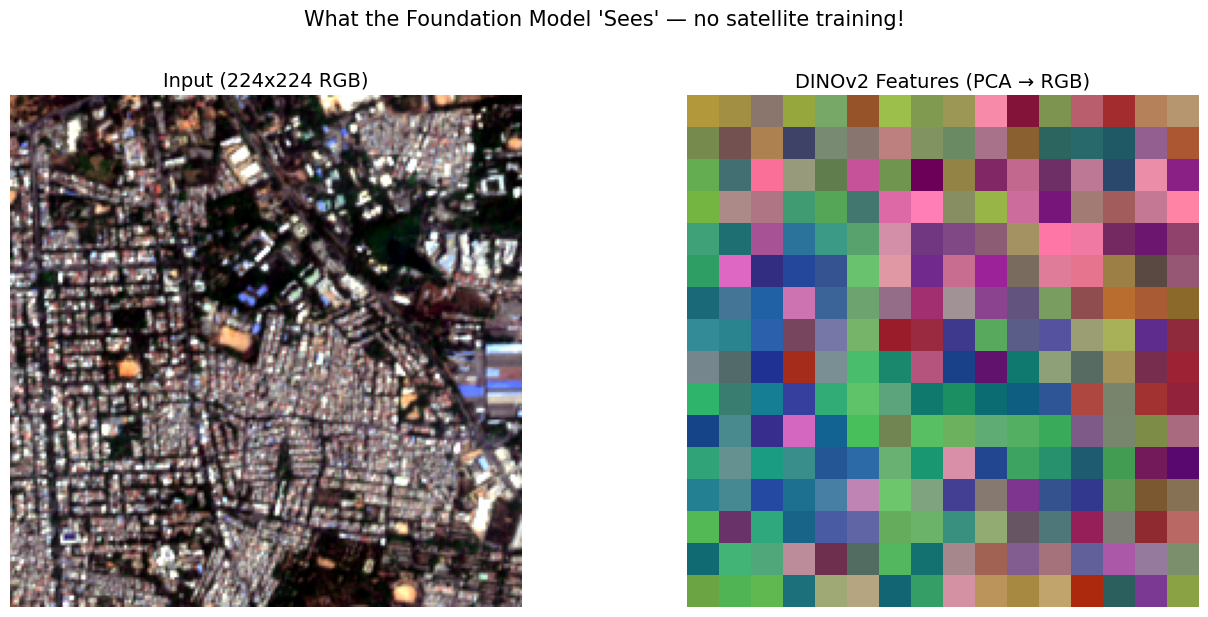

Similar colors = similar features. The model distinguishes water, vegetation,
and built-up areas purely from its general understanding of visual patterns.


In [4]:
from sklearn.decomposition import PCA

# Take a 224x224 center crop
cy, cx = h // 2, w // 2
crop = 224

r_crop = normalize_band(red[cy-crop//2:cy+crop//2, cx-crop//2:cx+crop//2])
g_crop = normalize_band(green[cy-crop//2:cy+crop//2, cx-crop//2:cx+crop//2])
b_crop = normalize_band(blue[cy-crop//2:cy+crop//2, cx-crop//2:cx+crop//2])

# DINOv2 expects ImageNet normalization
rgb_patch = np.stack([r_crop, g_crop, b_crop], axis=0).astype(np.float32)
mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
rgb_normed = (rgb_patch - mean) / std

input_patch = torch.from_numpy(rgb_normed).unsqueeze(0).float()

with torch.no_grad():
    features = dinov2.forward_features(input_patch)
    patch_tokens = features["x_norm_patchtokens"]  # (1, 256, 384)

grid_size = int(np.sqrt(patch_tokens.shape[1]))  # 16
print(f"Extracted {patch_tokens.shape[1]} patch embeddings ({grid_size}x{grid_size} grid)")
print(f"Each embedding has {patch_tokens.shape[2]} dimensions")

pca = PCA(n_components=3)
pca_result = pca.fit_transform(patch_tokens[0].numpy())
pca_image = pca_result.reshape(grid_size, grid_size, 3)
pca_image = (pca_image - pca_image.min()) / (pca_image.max() - pca_image.min())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
patch_rgb_vis = np.stack([r_crop, g_crop, b_crop], axis=-1)
axes[0].imshow(np.clip(patch_rgb_vis, 0, 1))
axes[0].set_title("Input (224x224 RGB)", fontsize=14)
axes[0].axis("off")
axes[1].imshow(pca_image)
axes[1].set_title("DINOv2 Features (PCA → RGB)", fontsize=14)
axes[1].axis("off")
plt.suptitle("What the Foundation Model 'Sees' — no satellite training!", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print("Similar colors = similar features. The model distinguishes water, vegetation,")
print("and built-up areas purely from its general understanding of visual patterns.")

## Step 4: Classify using Foundation Model + Spectral Features

DINOv2 only sees RGB — it's blind to NIR and SWIR. So we **combine** DINOv2's visual features with spectral index statistics per patch:

- **DINOv2 features (384-dim):** Captures texture, edges, spatial patterns from RGB
- **Spectral stats (9 values):** Mean, std, and median of MNDWI, NDVI, NDBI per patch — captures the domain-specific water/vegetation/built-up signals

We then train a **Random Forest** (not just a linear classifier) on these combined features for better accuracy.

In [5]:
%%time
from sklearn.ensemble import RandomForestClassifier
from utils import compute_ndvi, compute_mndwi, compute_ndbi

# Pre-compute spectral indices
mndwi = compute_mndwi(green, swir)
ndvi = compute_ndvi(nir, red)
ndbi = compute_ndbi(swir, nir)

# Pad image so tiles cover the entire image (no gaps at edges)
tile_size = 224
patch_dim = 14  # DINOv2 patch size in pixels
gs = tile_size // patch_dim  # 16 patches per tile side

# Pad to next multiple of tile_size
pad_h = (tile_size - h % tile_size) % tile_size
pad_w = (tile_size - w % tile_size) % tile_size

r_norm = np.pad(normalize_band(red), ((0, pad_h), (0, pad_w)), mode="reflect")
g_norm = np.pad(normalize_band(green), ((0, pad_h), (0, pad_w)), mode="reflect")
b_norm = np.pad(normalize_band(blue), ((0, pad_h), (0, pad_w)), mode="reflect")
mndwi_pad = np.pad(mndwi, ((0, pad_h), (0, pad_w)), mode="reflect")
ndvi_pad = np.pad(ndvi, ((0, pad_h), (0, pad_w)), mode="reflect")
ndbi_pad = np.pad(ndbi, ((0, pad_h), (0, pad_w)), mode="reflect")
lbl_pad = np.pad(threshold_cls, ((0, pad_h), (0, pad_w)), mode="reflect")

hp, wp = r_norm.shape
n_tiles_y = hp // tile_size
n_tiles_x = wp // tile_size
print(f"Padded image: {hp} x {wp} (original: {h} x {w})")
print(f"Tiles: {n_tiles_y} x {n_tiles_x} = {n_tiles_y * n_tiles_x}")

all_features = []
all_labels = []
all_positions = []  # (y, x) of each 14x14 patch in the padded image

print("Extracting DINOv2 features + spectral indices...")
for ty in range(n_tiles_y):
    for tx in range(n_tiles_x):
        y0 = ty * tile_size
        x0 = tx * tile_size

        # DINOv2 features from RGB tile
        rgb_in = np.stack([
            r_norm[y0:y0+tile_size, x0:x0+tile_size],
            g_norm[y0:y0+tile_size, x0:x0+tile_size],
            b_norm[y0:y0+tile_size, x0:x0+tile_size],
        ], axis=0).astype(np.float32)
        rgb_in = (rgb_in - mean) / std
        inp = torch.from_numpy(rgb_in).unsqueeze(0).float()

        with torch.no_grad():
            feats = dinov2.forward_features(inp)
            tokens = feats["x_norm_patchtokens"][0].numpy()  # (256, 384)

        # For each 14x14 patch: DINOv2 + spectral stats
        for py in range(gs):
            for px in range(gs):
                r0, c0 = py * patch_dim, px * patch_dim
                r1, c1 = r0 + patch_dim, c0 + patch_dim

                p_mndwi = mndwi_pad[y0+r0:y0+r1, x0+c0:x0+c1]
                p_ndvi = ndvi_pad[y0+r0:y0+r1, x0+c0:x0+c1]
                p_ndbi = ndbi_pad[y0+r0:y0+r1, x0+c0:x0+c1]

                # 9 spectral features: mean, std, median of each index
                spectral_feats = np.array([
                    p_mndwi.mean(), p_mndwi.std(), np.median(p_mndwi),
                    p_ndvi.mean(), p_ndvi.std(), np.median(p_ndvi),
                    p_ndbi.mean(), p_ndbi.std(), np.median(p_ndbi),
                ])

                combined = np.concatenate([tokens[py * gs + px], spectral_feats])
                all_features.append(combined)

                lbl_patch = lbl_pad[y0+r0:y0+r1, x0+c0:x0+c1]
                majority_label = np.bincount(lbl_patch.flatten(), minlength=4).argmax()
                all_labels.append(majority_label)
                all_positions.append((y0 + r0, x0 + c0))

X_fm = np.array(all_features)
y_fm = np.array(all_labels)
print(f"Extracted {len(X_fm)} feature vectors ({X_fm.shape[1]}-dim: 384 DINOv2 + 9 spectral)")

# Train a Random Forest on combined features (much better than linear)
clf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
clf.fit(X_fm, y_fm)
print(f"Random Forest accuracy: {clf.score(X_fm, y_fm):.3f}")

Padded image: 1792 x 2240 (original: 1683 x 2154)
Tiles: 8 x 10 = 80
Extracting DINOv2 features + spectral indices...
Extracted 20480 feature vectors (393-dim: 384 DINOv2 + 9 spectral)
Random Forest accuracy: 1.000
CPU times: user 50 s, sys: 1.19 s, total: 51.2 s
Wall time: 8 s


In [6]:
# Build classification map from predictions
fm_predictions = clf.predict(X_fm)

# Reconstruct on padded grid, then crop to original size
fm_padded = np.full((hp, wp), 3, dtype=np.int32)
for idx, (py, px) in enumerate(all_positions):
    fm_padded[py:py+patch_dim, px:px+patch_dim] = fm_predictions[idx]

# Crop back to original image size
fm_classification = fm_padded[:h, :w]

print(f"Foundation model map: {fm_classification.shape} (full coverage)")
for cid, (name, _) in LAND_COVER_CLASSES.items():
    count = (fm_classification == cid).sum()
    area = count * 100 / 1e6
    print(f"  {name:12s}: {area:.2f} km²")

Foundation model map: (1683, 2154) (full coverage)
  Water       : 6.13 km²
  Vegetation  : 32.26 km²
  Bare Soil   : 51.34 km²
  Built-up    : 272.79 km²


### "Wait — this still needs labels, just like Random Forest. So what's the point?"

Good question. In our demo, the foundation model uses the **same threshold labels** as the Random Forest in Notebook 03. With abundant labels on a single image, the advantage is not obvious.

The real value of foundation models shows up in scenarios **we're not demonstrating here**:

| Scenario | Without foundation model | With foundation model |
|----------|------------------------|-----------------------|
| **New city, no labels** | Collect labels from scratch, retrain | DINOv2 features + just 50-100 labeled patches → works |
| **Different season** | Summer model fails on monsoon imagery | DINOv2 features are robust to seasonal changes |
| **Very few labels** | Random Forest needs thousands of pixels | Rich features mean even tiny training sets work |
| **Transfer across regions** | Trained on Bangalore, fails on Chennai | Visual patterns generalize better |

**The key insight:** DINOv2's 384-dimensional features are so information-rich (learned from 142M images) that a simple classifier on top needs far fewer labeled examples to work well. In our demo we have millions of labeled pixels, so this advantage doesn't show — but in a real project where labeling is expensive and slow, this matters enormously.

**Think of it this way:**
- Random Forest on raw bands: like giving a fresh graduate a ruler and asking them to classify land use
- Foundation model features: like giving them 10 years of experience looking at satellite images — they need far fewer examples to "get it"

### The progression across this course

```
Method              Labels needed              Accuracy    Spatial context
──────────────────────────────────────────────────────────────────────────
Thresholds          Zero (we write rules)      Good        None
Random Forest       Thousands of pixels        Better      None  
U-Net               Hundreds of patches        Best        Yes (pixel-level)
Foundation Model    Tens of patches*           Good+       Partial (patch-level)

* The real promise — not fully shown in our single-image demo
```

## Step 5: Grand Comparison — All Methods

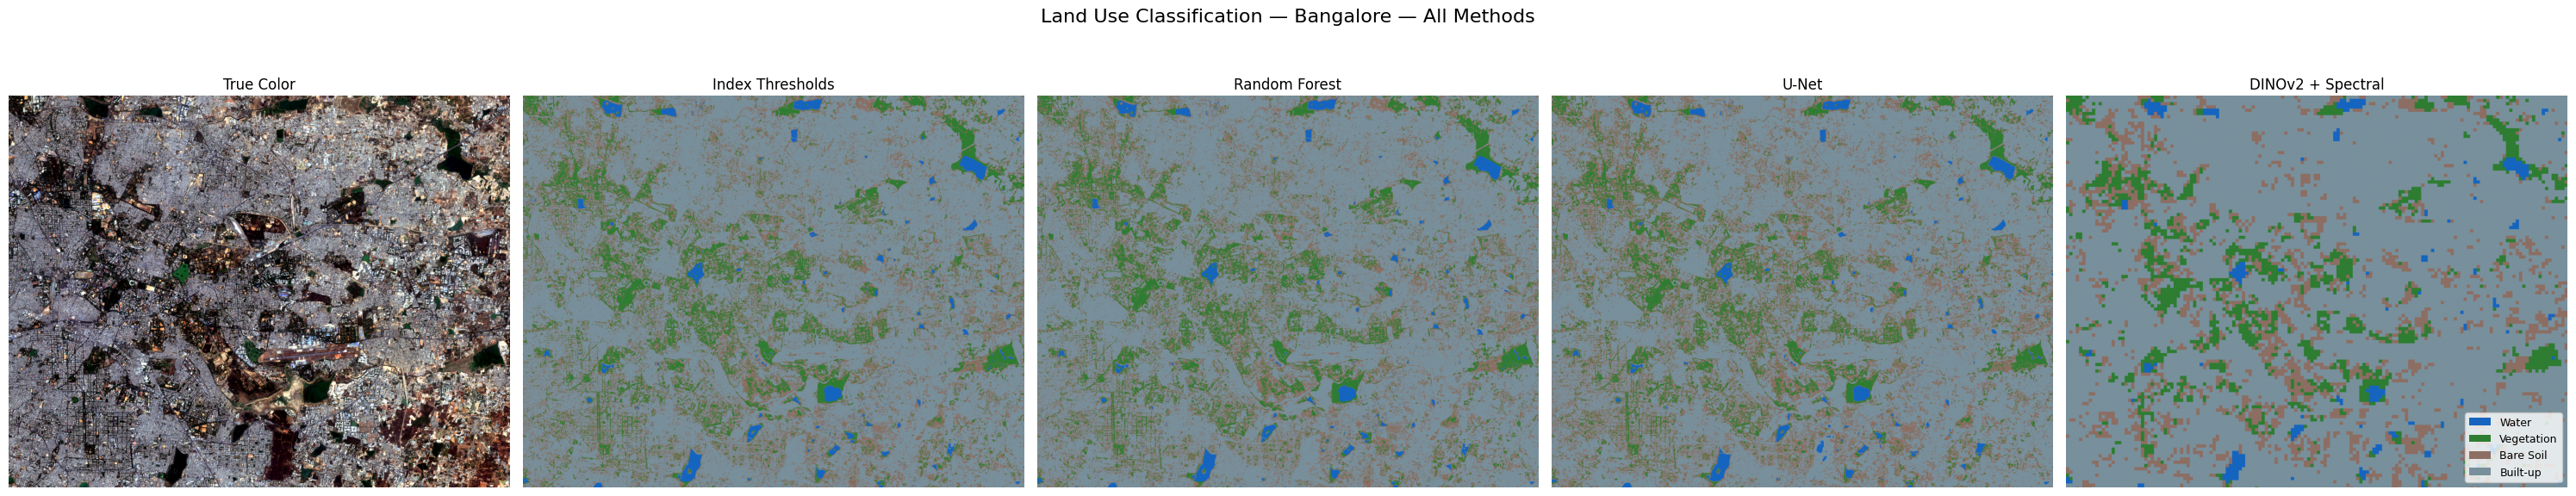


Water area detected by each method:
---------------------------------------------
  Index Thresholds    : 6.28 km²
  Random Forest       : 6.23 km²
  U-Net               : 5.58 km²
  DINOv2 + Spectral   : 6.13 km²


In [7]:
fig, axes = plt.subplots(1, 5, figsize=(30, 6))

titles = ["True Color", "Index Thresholds", "Random Forest", "U-Net", "DINOv2 + Spectral"]
images = [rgb, threshold_cls, rf_cls, unet_cls, fm_classification]
cmaps = [None, LAND_COVER_CMAP, LAND_COVER_CMAP, LAND_COVER_CMAP, LAND_COVER_CMAP]

for ax, img, title, cmap in zip(axes, images, titles, cmaps):
    if cmap:
        ax.imshow(img, cmap=cmap, vmin=0, vmax=3)
    else:
        ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

legend_patches = [plt.Rectangle((0, 0), 1, 1, fc=c) for _, (_, c) in LAND_COVER_CLASSES.items()]
axes[-1].legend(legend_patches, LAND_COVER_LABELS, loc="lower right", fontsize=9)

plt.suptitle("Land Use Classification — Bangalore — All Methods", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Water area table
print("\nWater area detected by each method:")
print("-" * 45)
for name, cls_map in [("Index Thresholds", threshold_cls), ("Random Forest", rf_cls),
                       ("U-Net", unet_cls), ("DINOv2 + Spectral", fm_classification)]:
    water_km2 = (cls_map == 0).sum() * 100 / 1e6
    print(f"  {name:20s}: {water_km2:.2f} km²")

## When to Use What — A Guide for Civil Engineers

| Method | Setup Time | Accuracy | Best For |
|--------|-----------|----------|----------|
| **Index thresholds** | Minutes | Good for water/veg | Quick assessment, field verification |
| **Random Forest** | Minutes | Better | When you have training samples |
| **U-Net** | Hours (training) | Best boundaries | Large-area mapping, production systems |
| **Foundation Model** | Minutes (fine-tune) | Best generalization | New areas with minimal labeled data |

## Applications in Water Resources

- **Lake monitoring**: Track surface area changes over seasons/years
- **Flood mapping**: Classify pre/post-flood images to measure inundation
- **Urban encroachment**: Detect construction near water bodies and flood zones
- **Watershed health**: Monitor vegetation cover changes affecting runoff
- **Water quality proxies**: Turbidity and algae can be estimated from spectral data

## The Open Ecosystem

- **TorchGeo** — PyTorch datasets/models for geospatial data
- **TerraTorch** — Fine-tune foundation models for Earth observation
- **Google Earth Engine** — Planetary-scale geospatial analysis (free for research)
- **QGIS** — Open-source GIS, integrates with Python outputs
- **Planetary Computer** — Free satellite data access (what we used)

## Key Takeaways

1. Foundation models bring **pre-trained visual understanding** to satellite imagery
2. Even models trained on natural photos (DINOv2) work on satellite data — specialized models (Prithvi, Clay) work even better
3. The progression: **Indices → Random Forest → U-Net → Foundation Models** — each adds capability
4. For water resources: these tools enable **automated, repeatable monitoring** at scale
5. **All tools used today are free and open source**

In [8]:
print("=" * 60)
print("COURSE SUMMARY")
print("=" * 60)
print()
print("What we covered:")
print("  1. Getting free satellite data (Sentinel-2 via STAC)")
print("  2. Spectral indices for water detection (NDWI, MNDWI)")
print("  3. ML classification (Random Forest, U-Net)")
print("  4. Foundation models (DINOv2 linear probing)")
print()
print("What you can do next:")
print("  • Change the bbox to monitor YOUR area of interest")
print("  • Compare two dates to detect changes")
print("  • Use MNDWI for flood extent mapping")
print("  • Fine-tune Prithvi-EO for satellite-specific tasks")
print()
print("All code is in this repo — clone it and start exploring!")

COURSE SUMMARY

What we covered:
  1. Getting free satellite data (Sentinel-2 via STAC)
  2. Spectral indices for water detection (NDWI, MNDWI)
  3. ML classification (Random Forest, U-Net)
  4. Foundation models (DINOv2 linear probing)

What you can do next:
  • Change the bbox to monitor YOUR area of interest
  • Compare two dates to detect changes
  • Use MNDWI for flood extent mapping
  • Fine-tune Prithvi-EO for satellite-specific tasks

All code is in this repo — clone it and start exploring!
